/var/folders/5l/xvvkbgln1qz502f2b5fvbfj40000gn/T/ipykernel_8300/4219045712.py:7: DeprecationWarning: The parameter `use_angle_cls` has been deprecated and will be removed in the future. Please use `use_textline_orientation` instead.
  ocr = PaddleOCR(use_angle_cls=True, lang='en')
Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/vi/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/vi/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/vi/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files.


image 1/1 /Users/vi/TTCS/source/SourceCodePlate/training/../samples/img_plate_12.png: 736x960 5 plates, 278.5ms
Speed: 19.5ms preprocess, 278.5ms inference, 14.3ms postprocess per image at shape (1, 3, 736, 960)


/var/folders/5l/xvvkbgln1qz502f2b5fvbfj40000gn/T/ipykernel_8300/4219045712.py:27: DeprecationWarning: Please use `predict` instead.
  result = ocr.ocr(crop)


Plate: 28-H1 630.89 | Confidence: 1.00
Plate: 15-B2 098.70 | Confidence: 0.98
Plate: AT-74 O0'00O | Confidence: 0.60
Plate: 22 EL9 | Confidence: 0.75
Plate: 29-Y5 144.5 | Confidence: 0.97


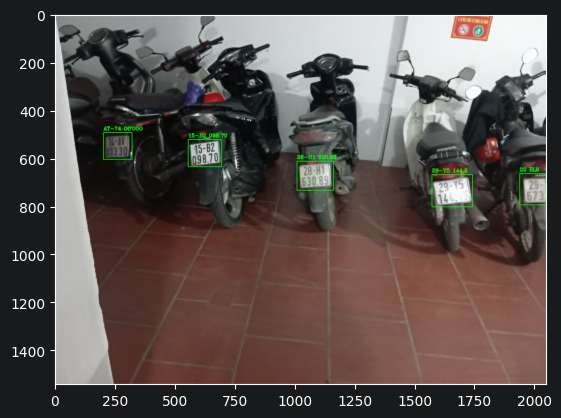

In [2]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
from paddleocr import PaddleOCR
import cv2

model = YOLO("../model/best_plate_detection.pt")
ocr = PaddleOCR(use_angle_cls=True, lang='en')
predict = model("../samples/img_plate_12.png")
img = cv2.imread("../samples/img_plate_12.png")

for r in predict:

    boxes = r.boxes.xyxy

    for box in boxes:
        x1, y1, x2, y2 = map(int, box)

        offset_w = int((x2 - x1) * 0.1)
        offset_h = int((y2 - y1) * 0.2)
        x1_crop = max(0, x1 - offset_w)
        y1_crop = max(0, y1 - offset_h)
        x2_crop = min(img.shape[1], x2 + 2*offset_w)
        y2_crop = min(img.shape[0], y2 + 2*offset_h)

        crop = img[y1_crop:y2_crop, x1_crop:x2_crop]
        # cv2.imwrite("crop.png", crop)
        result = ocr.ocr(crop)
        plate = ""
        if result:
            texts = result[0]['rec_texts']
            scores = result[0]['rec_scores']
            plate = " ".join(texts)
        if len(scores) > 0:
            conf = sum(scores)/len(scores)

        if conf > 0:
            cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)
            cv2.putText(img, plate, (x1, y1-10), cv2.FONT_HERSHEY_COMPLEX, 0.7, (0,255,0), 2)
        print(f"Plate: {plate} | Confidence: {conf:.2f}")
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_RGB2BGR))